In [1]:
import os
import numpy as np
import itertools
from os.path import join
import matplotlib.pyplot as plt
import sys

In [2]:
parent_path = '/data/cschmidt/excited_states/data_energy/fr0_data_max_crit/additional_energies'

file_paths = [join(parent_path, file_name) for file_name in os.listdir(parent_path) if file_name.endswith('.dat')]
target_paths = [join(parent_path, f'{file_path.split("/")[-1].split(".")[0]}_reduced.dat') for file_path in file_paths]

Ha2eV = 27.211396132

n_atoms = 45

In [3]:
def grouper(iterable, n, fillvalue = None):
    """
    Reads chunks of n lines from iterable. Fills missing lines at the end with fillvalue.
    Taken from the recipes in the itertools docs.
    """
    args = [iter(iterable)] * n
    return itertools.zip_longest(*args, fillvalue=fillvalue)

def extract_en_osc(file_path):
    energy, osc = [], []
    lines_one_molecule = n_atoms + 2
    with open(file_path, 'r') as f:
        for n, line in enumerate(f):
            if n % lines_one_molecule == 0:
                line = line.split()
                energy.append(float(line[0]))
                osc.append(float(line[1]))

    energy, osc = np.array(energy), np.array(osc)

    energy_eV = energy * Ha2eV
    return energy, energy_eV, osc

def check_for_en_osc_too_high(energy_eV, energy, osc):
    energy_eV_new, osc_new = [], []
    # Count the number of energy values above a certrain threshold
    threshold = 4.5
    count = 0
    values, values_hartree = [], []
    for e, e_hartree, o in zip(energy_eV, energy, osc):
        if e > threshold:
            count += 1
            values.append(e)
            values_hartree.append(e_hartree)
        else:
            energy_eV_new.append(e)
            osc_new.append(o)
    print(count)
    print(values)
    print(values_hartree)
    print(len(energy_eV), len(osc))
    print(len(energy_eV_new), len(osc_new))
    return count

def write_to_file_threshold_energy(file_path, target_path, threshold):
    lines_one_molecule = n_atoms + 2
    with open(file_path, 'r') as f_source, open(target_path, 'w') as f_target:
        f_source = f_source.readlines()
        for grouper_lines in grouper(f_source, lines_one_molecule):
            energy_line = grouper_lines[0].split()
            energy = float(energy_line[0])
            energy_eV = energy * Ha2eV
            if energy_eV <= threshold:
                for line in grouper_lines:
                    if line is not None:
                        f_target.write(line)

In [4]:
threshold = 4.5

for n, (file_path, target_path) in enumerate(zip(file_paths, target_paths)):
    file_name = file_path.split("/")[-1]
    print(file_name)
    energy, energy_eV, osc = extract_en_osc(file_path)
    count = check_for_en_osc_too_high(energy_eV, energy, osc)
    if count > 0:
        write_to_file_threshold_energy(file_path, target_path, threshold)
    # if n == 0: sys.exit()
    print('\n')

train_solvent_dmf_traj_correct_energy_osc.dat
0
[]
[]
15377 15377
15377 15377


train_solvent_hexane_traj_correct_energy_osc.dat
0
[]
[]
17607 17607
17607 17607


train_solvent_dioxan_traj_wrong_energy_osc.dat
0
[]
[]
5607 5607
5607 5607


train_solvent_acetone_traj_wrong_energy_osc.dat
1
[3682.1831158108084]
[135.3176844712]
3393 3393
3392 3392


train_solvent_acetone_traj_correct_energy_osc.dat
0
[]
[]
12663 12663
12663 12663


train_solvent_dmso_traj_correct_energy_osc.dat
0
[]
[]
15687 15687
15687 15687


train_solvent_dmso_traj_wrong_energy_osc.dat
1
[1504.1676388097148]
[55.277121082399994]
661 661
660 660


train_solvent_meoh_traj_wrong_energy_osc.dat
1
[45882.11598249496]
[1686.1360497611]
6466 6466
6465 6465


train_solvent_hexan_traj_wrong_energy_osc.dat
0
[]
[]
6965 6965
6965 6965


train_solvent_dmf_traj_wrong_energy_osc.dat
0
[]
[]
6618 6618
6618 6618


train_solvent_dioxane_traj_correct_energy_osc.dat
0
[]
[]
14174 14174
14174 14174


train_solvent_acn_traj_wrong_energy_o

In [7]:
# Count the number of osc values above a certrain threshold
threshold_osc = 1.3
count = 0
values = []
for o in osc:
    if o > threshold_osc:
        count += 1.0
        values.append(o)
print(count)
print(values)

3.0
[58.64860399, 20.46121118, 2332.48229908]


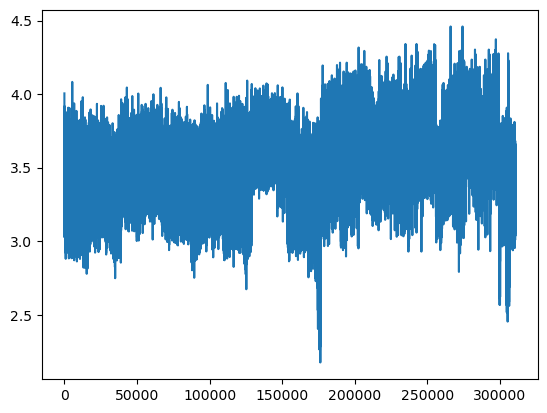

In [9]:
# plt.plot([i for i in range(len(energy_eV))], energy_eV)
# plt.show()

plt.plot([i for i in range(len(energy_eV_new))], energy_eV_new)
plt.show()

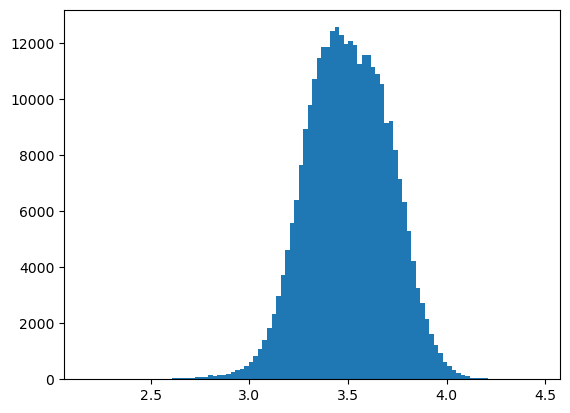

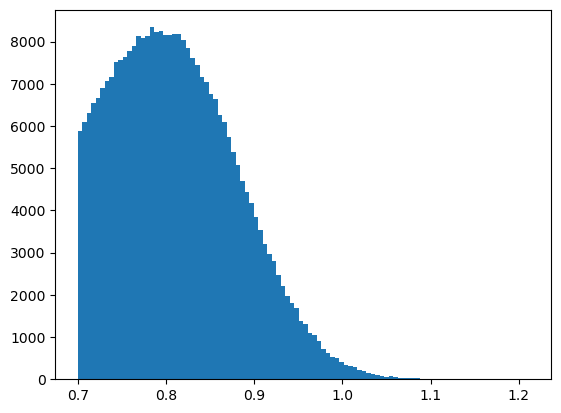

In [10]:
plt.hist(energy_eV_new, bins=100)
plt.show()

plt.hist(osc_new, bins=100)
plt.show()